# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## Enter The Frontier!

And now - we put Frontier Models to the test.

### 2 important points:

It's important to appreciate that we aren't Training the frontier models. We're only providing them with the Test dataset to see how they perform. They don't gain the benefit of the 400,000 training examples that we provided to the Traditional ML models.

HAVING SAID THAT...

It's entirely possible that in their monstrously large training data, they've already been exposed to all the products in the training AND the test set. So there could be test "contamination" here which gives them an unfair advantage. We should keep that in mind.

In [ ]:
# imports

import os
import re
# import math
# import json
# import random
from dotenv import load_dotenv
from huggingface_hub import login
from items import Item
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [2]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from testing import Tester

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', 'your-key-if-not-using-env')
os.environ['ANTHROPIC_API_KEY'] = os.getenv('ANTHROPIC_API_KEY', 'your-key-if-not-using-env')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', 'your-key-if-not-using-env')

In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
openai = OpenAI()
claude = Anthropic()

In [6]:
%matplotlib inline

In [7]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train_lite.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test_lite.pkl', 'rb') as file:
    test = pickle.load(file)

# Before we look at the Frontier

## There is one more model we could consider

In [8]:
# Write the test set to a CSV

import csv
with open('human_input.csv', 'w') as csvfile:
    writer = csv.writer(csvfile)
    for t in test[:250]:
        writer.writerow([t.test_prompt(), 0])

In [9]:
# Read it back in

human_predictions = []
with open('human_output.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    for row in reader:
        human_predictions.append(float(row[1]))

In [10]:
def human_pricer(item):
    idx = test.index(item)
    return human_predictions[idx]

1: Guess: $120.00 Truth: $18.99 Error: $101.01 SLE: 3.24 Item: BLACK High Temperature Header Exhaust Pi...
2: Guess: $80.00 Truth: $14.20 Error: $65.80 SLE: 2.80 Item: Clobeau Portable Handheld Expanding File...
3: Guess: $35.00 Truth: $12.99 Error: $22.01 SLE: 0.89 Item: Cell Phone Ring Holder Finger Stand, Luc...
4: Guess: $350.00 Truth: $23.99 Error: $326.01 SLE: 6.98 Item: GPC Image Compatible Toner Cartridge Rep...
5: Guess: $75.00 Truth: $699.99 Error: $624.99 SLE: 4.94 Item: ASUS TUF Gaming Laptop, 15.6Â” Full HD I...
6: Guess: $12.00 Truth: $14.99 Error: $2.99 SLE: 0.04 Item: Life Q30 / Q35 Earpads - defean Replacem...
7: Guess: $115.00 Truth: $6.23 Error: $108.77 SLE: 7.70 Item: Prime Products 28-0113 Black Stick On 5t...
8: Guess: $100.00 Truth: $52.99 Error: $47.01 SLE: 0.39 Item: Radiomaster TX16S SE TX18S Universal Por...
9: Guess: $300.00 Truth: $50.91 Error: $249.09 SLE: 3.09 Item: For Toyota Highlander 2010 2011 2012 201...
10: Guess: $80.00 Truth: $15.45 Error: $64.55 

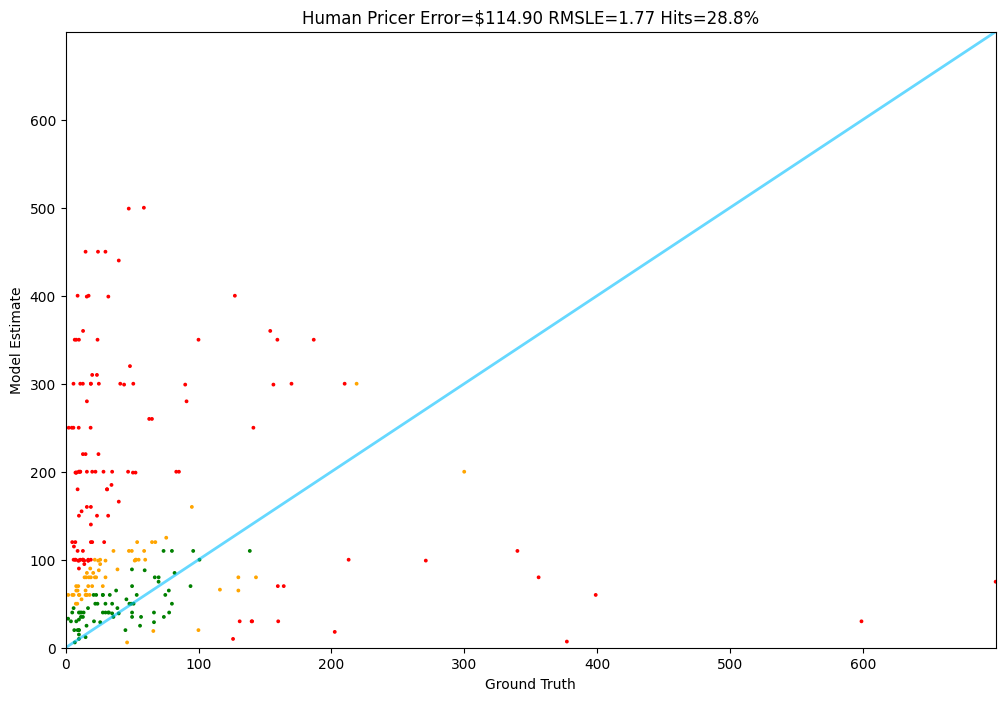

In [11]:
Tester.test(human_pricer, test)

## First, the humble but mighty GPT-4o-mini

It's called mini, but it packs a punch.

In [12]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible, 
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [13]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': "How much does this cost?\n\nBLACK High Temperature Header Exhaust Pipe Insulation Wrap Roll Black 1/16 X 2 X 50' - Thermal Zero\nWidth (in) 2 in Length (ft) 50 feet Wrap Material Thermal Fiber Wrap Color Black Temperature Rating (degrees F) 2000 degree Fahrenheit Instillation Stainless Ties (sold separately) Thickness (in) 1/16 (.063 in) Quantity 1 Roll Thermal Zero header wraps utilizes our own thermal technology to provide superior protection from heat that may exit the exhaust pipe. They lower engine bay temperatures and help to create more horsepower. Our wrap can withstand temperatures of up 2000 degrees Fahrenheit. The wraps provide great protection for motorcycle pipes, while also creating that old school look. Our wraps contain NO ASBESTOS. High temperature exhaust wrap can"},
 {'role': 'assistant', 'content': 'Price is $'}]

In [14]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [15]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [16]:
# The function for gpt-4o-mini

def gpt_4o_mini(item):
    response = openai.chat.completions.create(
        model="gpt-4o-mini", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [17]:
test[0].price

18.99

1: Guess: $47.99 Truth: $18.99 Error: $29.00 SLE: 0.80 Item: BLACK High Temperature Header Exhaust Pi...
2: Guess: $15.99 Truth: $14.20 Error: $1.79 SLE: 0.01 Item: Clobeau Portable Handheld Expanding File...
3: Guess: $10.99 Truth: $12.99 Error: $2.00 SLE: 0.02 Item: Cell Phone Ring Holder Finger Stand, Luc...
4: Guess: $29.99 Truth: $23.99 Error: $6.00 SLE: 0.05 Item: GPC Image Compatible Toner Cartridge Rep...
5: Guess: $600.00 Truth: $699.99 Error: $99.99 SLE: 0.02 Item: ASUS TUF Gaming Laptop, 15.6Â” Full HD I...
6: Guess: $15.99 Truth: $14.99 Error: $1.00 SLE: 0.00 Item: Life Q30 / Q35 Earpads - defean Replacem...
7: Guess: $9.99 Truth: $6.23 Error: $3.76 SLE: 0.18 Item: Prime Products 28-0113 Black Stick On 5t...
8: Guess: $47.99 Truth: $52.99 Error: $5.00 SLE: 0.01 Item: Radiomaster TX16S SE TX18S Universal Por...
9: Guess: $85.00 Truth: $50.91 Error: $34.09 SLE: 0.25 Item: For Toyota Highlander 2010 2011 2012 201...
10: Guess: $23.99 Truth: $15.45 Error: $8.54 SLE: 0.17 Item: 

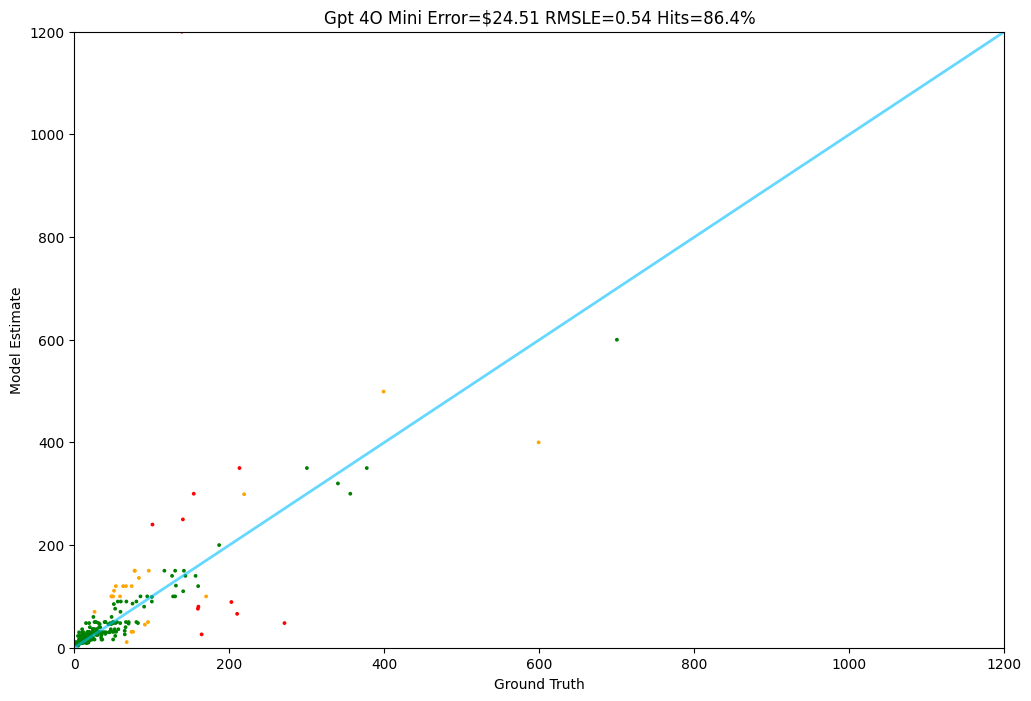

In [18]:
Tester.test(gpt_4o_mini, test)

In [19]:
# The function for gpt-4o - the August model

def gpt_4o_frontier(item):
    response = openai.chat.completions.create(
        model="gpt-4o-2024-08-06", 
        messages=messages_for(item),
        seed=42,
        max_tokens=5
    )
    reply = response.choices[0].message.content
    return get_price(reply)

1: Guess: $30.00 Truth: $18.99 Error: $11.01 SLE: 0.19 Item: BLACK High Temperature Header Exhaust Pi...
2: Guess: $13.99 Truth: $14.20 Error: $0.21 SLE: 0.00 Item: Clobeau Portable Handheld Expanding File...
3: Guess: $10.99 Truth: $12.99 Error: $2.00 SLE: 0.02 Item: Cell Phone Ring Holder Finger Stand, Luc...
4: Guess: $23.99 Truth: $23.99 Error: $0.00 SLE: 0.00 Item: GPC Image Compatible Toner Cartridge Rep...
5: Guess: $550.00 Truth: $699.99 Error: $149.99 SLE: 0.06 Item: ASUS TUF Gaming Laptop, 15.6Â” Full HD I...
6: Guess: $10.99 Truth: $14.99 Error: $4.00 SLE: 0.08 Item: Life Q30 / Q35 Earpads - defean Replacem...
7: Guess: $10.99 Truth: $6.23 Error: $4.76 SLE: 0.26 Item: Prime Products 28-0113 Black Stick On 5t...
8: Guess: $30.00 Truth: $52.99 Error: $22.99 SLE: 0.31 Item: Radiomaster TX16S SE TX18S Universal Por...
9: Guess: $80.00 Truth: $50.91 Error: $29.09 SLE: 0.20 Item: For Toyota Highlander 2010 2011 2012 201...
10: Guess: $14.99 Truth: $15.45 Error: $0.46 SLE: 0.00 Ite

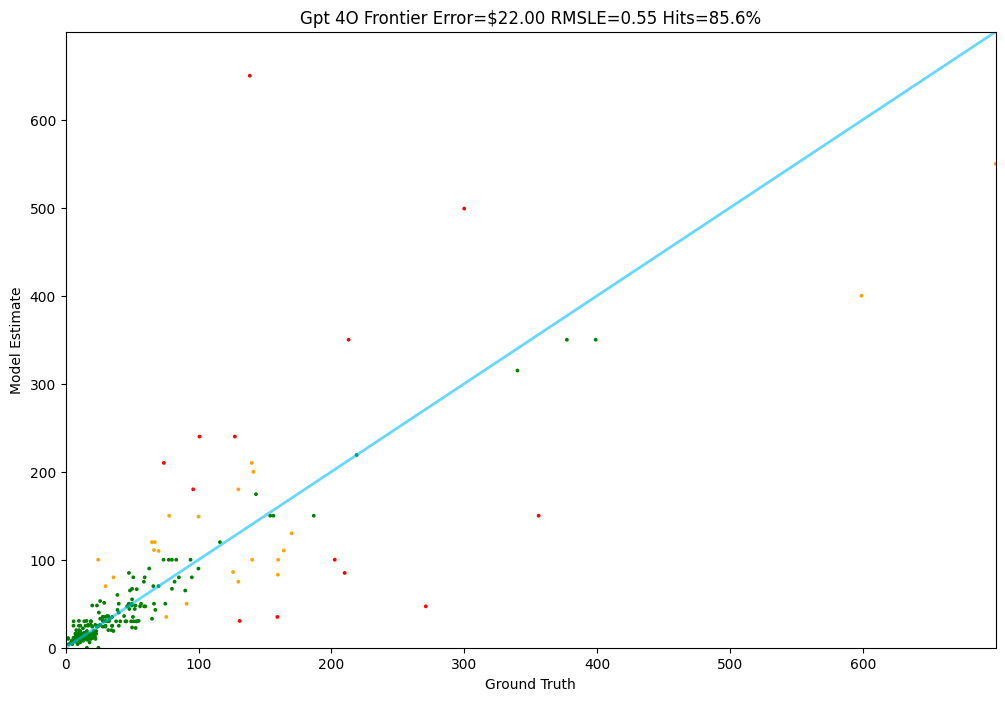

In [20]:
Tester.test(gpt_4o_frontier, test)

In [21]:
def claude_3_point_5_sonnet(item):
    messages = messages_for(item)
    system_message = messages[0]['content']
    messages = messages[1:]
    response = claude.messages.create(
        model="claude-3-5-sonnet-20240620",
        max_tokens=5,
        system=system_message,
        messages=messages
    )
    reply = response.content[0].text
    return get_price(reply)

1: Guess: $22.99 Truth: $18.99 Error: $4.00 SLE: 0.03 Item: BLACK High Temperature Header Exhaust Pi...
2: Guess: $14.99 Truth: $14.20 Error: $0.79 SLE: 0.00 Item: Clobeau Portable Handheld Expanding File...
3: Guess: $9.99 Truth: $12.99 Error: $3.00 SLE: 0.06 Item: Cell Phone Ring Holder Finger Stand, Luc...
4: Guess: $21.99 Truth: $23.99 Error: $2.00 SLE: 0.01 Item: GPC Image Compatible Toner Cartridge Rep...
5: Guess: $599.99 Truth: $699.99 Error: $100.00 SLE: 0.02 Item: ASUS TUF Gaming Laptop, 15.6Â” Full HD I...
6: Guess: $17.99 Truth: $14.99 Error: $3.00 SLE: 0.03 Item: Life Q30 / Q35 Earpads - defean Replacem...
7: Guess: $9.99 Truth: $6.23 Error: $3.76 SLE: 0.18 Item: Prime Products 28-0113 Black Stick On 5t...
8: Guess: $24.99 Truth: $52.99 Error: $28.00 SLE: 0.53 Item: Radiomaster TX16S SE TX18S Universal Por...
9: Guess: $60.00 Truth: $50.91 Error: $9.09 SLE: 0.03 Item: For Toyota Highlander 2010 2011 2012 201...
10: Guess: $19.99 Truth: $15.45 Error: $4.54 SLE: 0.06 Item: S

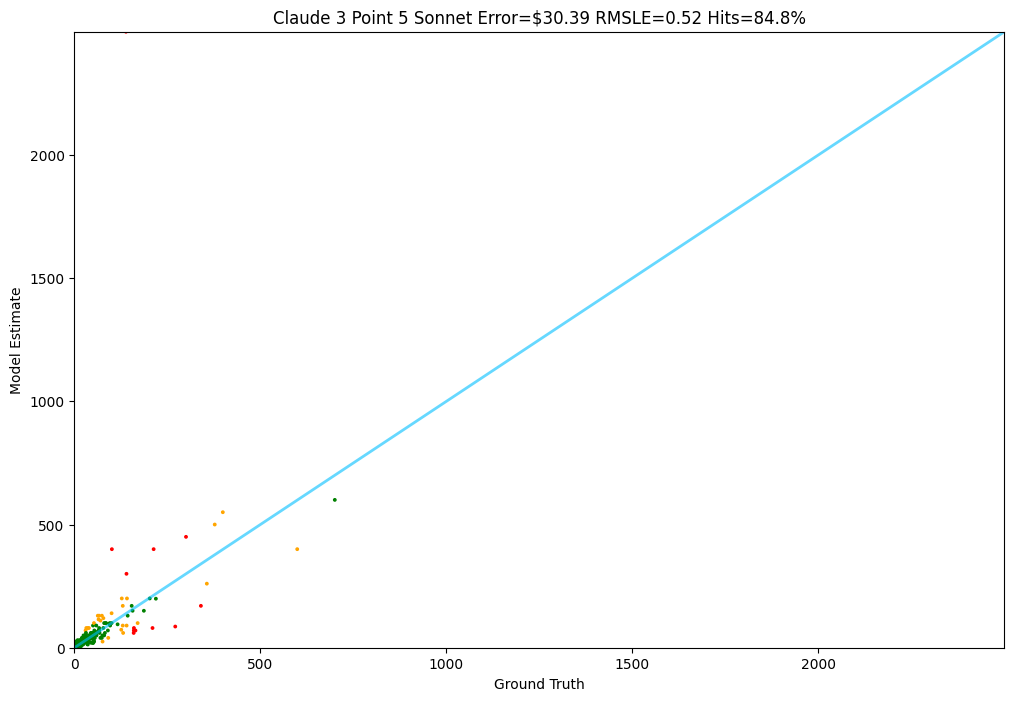

In [22]:
Tester.test(claude_3_point_5_sonnet, test)